# DSP Assignment-2: Transform Analysis: Examine the example

已知以下 z transform  
$$
H(z) =
\underbrace{\frac{\left(1 - 0.98e^{j 0.8\pi}z^{-1}\right)\left(1 - 0.98e^{-j 0.8\pi}z^{-1}\right)}
{\left(1 - 0.8e^{j 0.4\pi}z^{-1}\right)\left(1 - 0.8e^{-j 0.4\pi}z^{-1}\right)}}_{H_1(z)}
\underbrace{\prod_{k=1}^{4} \left(\frac{\left(c_k^* - z^{-1}\right)\left(c_k - z^{-1}\right)}
{\left(1 - c_k z^{-1}\right)\left(1 - c_k^* z^{-1}\right)}\right)^2}_{H_2(z)}
$$
with $c_k=0.95e^{j(0.95\pi+0.02\pi k)}$ for k=1,2,3,4  
接下來會先製作濾波器，接著分析濾波器響應，再產生輸入訊號，最後分析輸出訊號。

In [ ]:
!pip install numpy scipy matplotlib

## 安裝 Python 必要的函式庫

In [10]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
print("--- 匯入函式 ---")

--- 匯入函式 ---


## 1. 建立濾波器H(z)
首先計算 $c_k=0.95e^{j(0.95\pi+0.02\pi k)}$ for k=1,2,3,4 ，產生 ck 陣列。

In [11]:
# --- 建立濾波器 H(z) ---

#  k = [1, 2, 3, 4]
k = np.arange(1, 5) 

# caculate c_k
# 1j = j 
# np.pi = π
ck = 0.95 * np.exp(1j * (0.15 * np.pi + 0.02 * k * np.pi))

print("ck array (len: %d)" % len(ck))
print(ck)

ck array (len: 4)
[0.81770493+0.48358934j 0.78572655+0.53397921j 0.75064726+0.5822617j
 0.71260552+0.62824627j]


## 計算濾波器的 Poles and Zeros
將 H1 和 H2 的 Poles and Zeros 合在一起，並一起放入 signal.zpk2tf(zeros, poles, gain) 可以得出濾波器的係數 (b 、 a)

In [12]:
print("--- 1: Poles and Zeros ---")

# H1 
# Pole = 0.8 * e^(±j0.4π)
p_h1 = 0.8 * np.exp(1j * 0.4 * np.pi)
poles_h1 = [p_h1, np.conj(p_h1)] # 共軛

# Zero = 0.98 * e^(±j0.8π)
z_h1 = 0.98 * np.exp(1j * 0.8 * np.pi)
zeros_h1 = [z_h1, np.conj(z_h1)] # 共軛


# Product
# ck 、共軛
poles_product = np.concatenate((ck, np.conj(ck)))


# z = 1/ck 、共軛
zeros_product = np.concatenate((1/ck, 1/np.conj(ck)))


# Combine All
# Product needs to be added twice (square)
all_poles = np.concatenate((poles_h1, poles_product, poles_product))
all_zeros = np.concatenate((zeros_h1, zeros_product, zeros_product))
print("All Poles:", all_poles)
print("All Zeros:", all_zeros)
print(f"Total Poles: {len(all_poles)}")
print(f"Total Zeros: {len(all_zeros)}")

print("---  Convert Zero-Pole to Transfer Function  ---")
# gain = 1
b, a = signal.zpk2tf(all_zeros, all_poles, 1)
# (numberator, denominator) = signal.zpk2tf(zeros, poles, gain)
print("H=Y/X = b/a")
print("b :", b)
print("a :", a)

--- 1: Poles and Zeros ---
All Poles: [0.2472136 +0.76084521j 0.2472136 -0.76084521j 0.81770493+0.48358934j
 0.78572655+0.53397921j 0.75064726+0.5822617j  0.71260552+0.62824627j
 0.81770493-0.48358934j 0.78572655-0.53397921j 0.75064726-0.5822617j
 0.71260552-0.62824627j 0.81770493+0.48358934j 0.78572655+0.53397921j
 0.75064726+0.5822617j  0.71260552+0.62824627j 0.81770493-0.48358934j
 0.78572655-0.53397921j 0.75064726-0.5822617j  0.71260552-0.62824627j]
All Zeros: [-0.79283665+0.57602955j -0.79283665-0.57602955j  0.90604424-0.53583307j
  0.87061113-0.59166671j  0.83174212-0.64516532j  0.7895906 -0.69611775j
  0.90604424+0.53583307j  0.87061113+0.59166671j  0.83174212+0.64516532j
  0.7895906 +0.69611775j  0.90604424-0.53583307j  0.87061113-0.59166671j
  0.83174212-0.64516532j  0.7895906 -0.69611775j  0.90604424+0.53583307j
  0.87061113+0.59166671j  0.83174212+0.64516532j  0.7895906 +0.69611775j]
Total Poles: 18
Total Zeros: 18
---  Convert Zero-Pole to Transfer Function  ---
H=Y/X = b/a

pole、zero數量為 H1 : 2個 + H2 (k,共軛,平方) : $4\times 2\times 2$ 個  總計:18個

## 2. 分析濾波器
首先設定 $\omega$ 的範圍為 $-\pi$ 到 $\pi$  ，接著透過剛剛產生的 a、b 輸入進 signal.freqz(b, a, worN=w) 可以得到 $h = H(e^{jω})$。  
先分析相位，透過輸入 h 到 np.angle(h) 、 np.unwrap(phase) 可以得到 Principal Value Phase 和 Continuous Phase 。
接著透過 -np.gradient() 微分得出 group delay，之後取出 np.abs(h) 作為 Magnitude。  
最後畫出 Phase、Group delay、Magnitude的響應。


--- 2: Analyze Filter ---


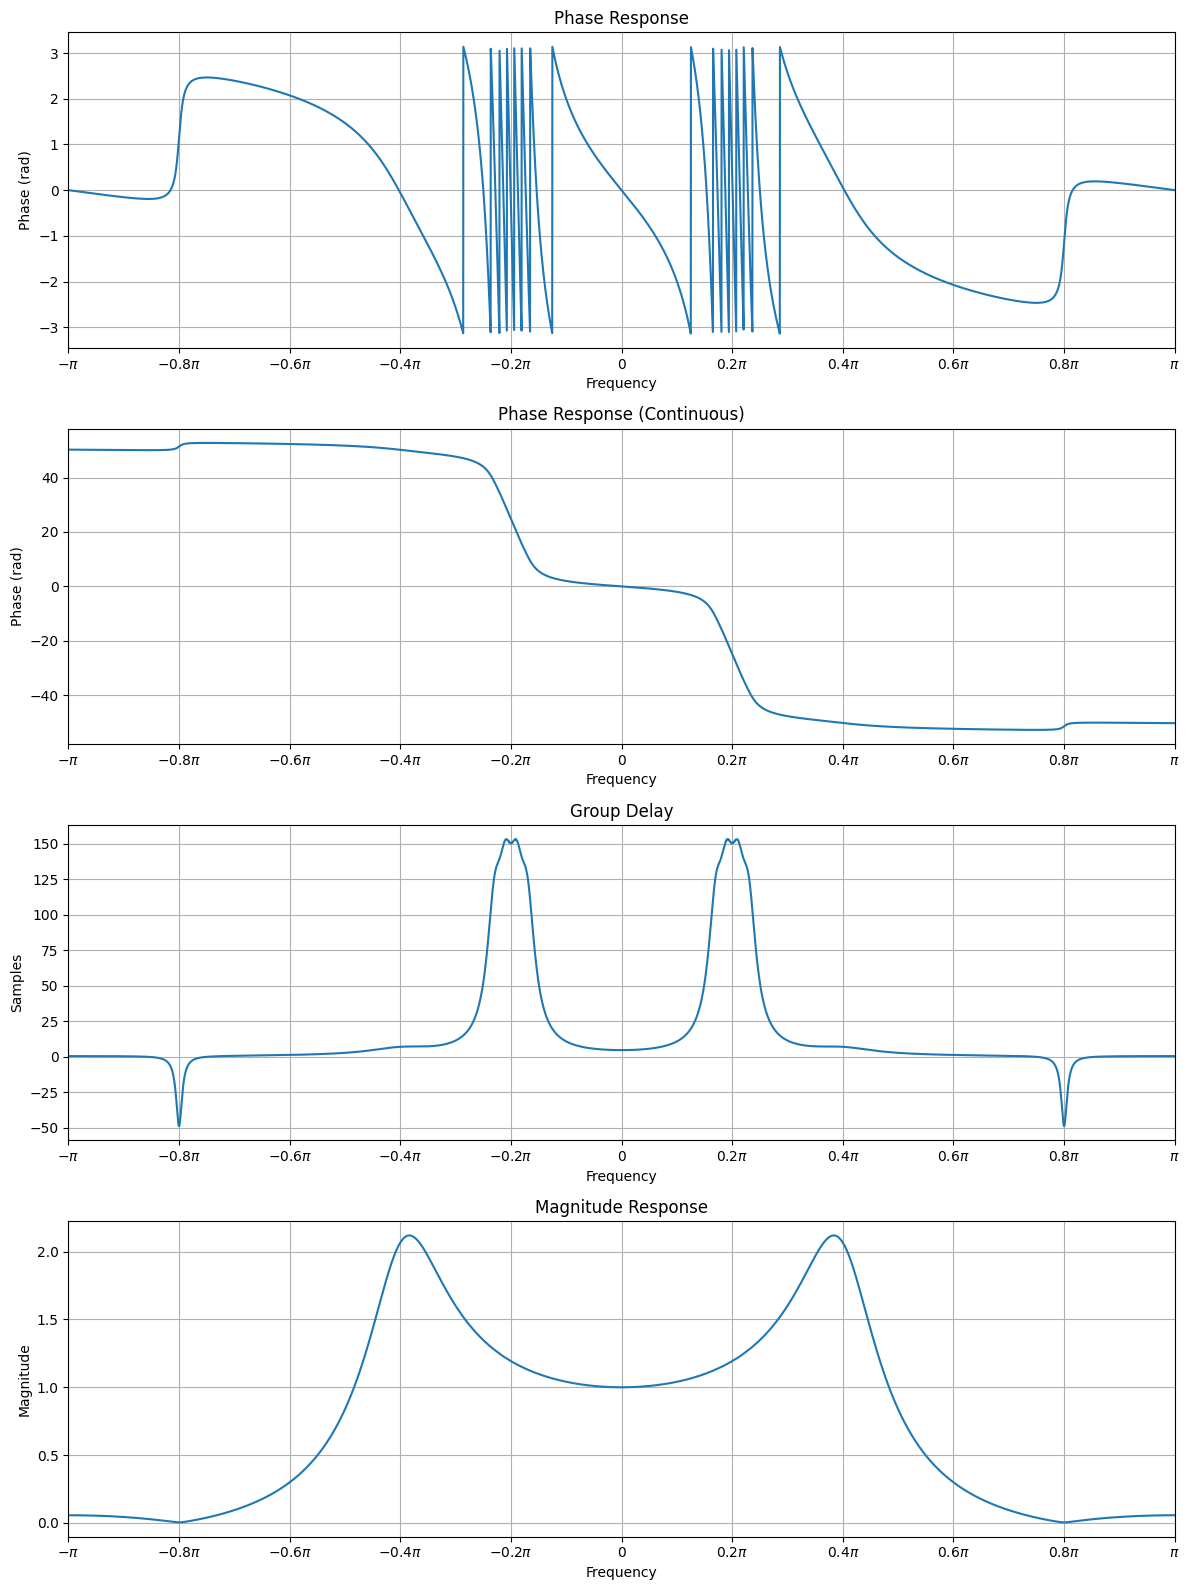

Analysis complete!


In [13]:
print("\n--- 2: Analyze Filter ---")

# omega from -π to π
# 8192 samples
w = np.linspace(-np.pi, np.pi, 8192)

# Calculate Frequency Response
# b/a = H(z)
# 0 ~ π 8192 samples
# w = omega 
# h = H(e^(jω))
_, h = signal.freqz(b, a, worN=w)

# Phase Response 
# angle = tan^(-1)(Im/Re)
# -180 ~ 180
phase = np.angle(h)
# convert from -π~π to continuous
phase_unwrapped = np.unwrap(phase)
# normalize phase
# frequency 0 index
freq0_index = np.argmin(np.abs(w)) 
shift = phase_unwrapped[freq0_index]
# normalized phase
phase_shifted = phase_unwrapped - shift 

# Group Delay
# Group Delay = - phase slope
# slope = d(phase)/d(omega)
group_delay = -np.gradient(phase_unwrapped, w)

# Magnitude Response
magnitude = np.abs(h)
# normalize magnitude
gain = magnitude[freq0_index] #  w=0 gain=7
magnitude_normalized = magnitude / gain

# --- Draw ---
plt.figure(figsize=(12, 16))

ticks = [-np.pi, -0.8*np.pi, -0.6*np.pi, -0.4*np.pi, -0.2*np.pi, 0, 0.2*np.pi, 0.4*np.pi, 0.6*np.pi, 0.8*np.pi, np.pi]
labels = [r'$-\pi$', r'$-0.8\pi$', r'$-0.6\pi$', r'$-0.4\pi$', r'$-0.2\pi$', '0', r'$0.2\pi$', r'$0.4\pi$', r'$0.6\pi$', r'$0.8\pi$', r'$\pi$']

# Phase Response 
plt.subplot(4, 1, 1)
plt.plot(w, phase)
plt.title('Phase Response')
plt.xlabel('Frequency')
plt.ylabel('Phase (rad)')
plt.xlim([-np.pi, np.pi])
plt.xticks(ticks, labels)
plt.grid(True)

# Plot 2: Phase Response (Continuous)
plt.subplot(4, 1, 2)
plt.plot(w, phase_shifted)
plt.title('Phase Response (Continuous)')
plt.xlabel('Frequency')
plt.ylabel('Phase (rad)')
plt.xlim([-np.pi, np.pi])
plt.xticks(ticks, labels)
plt.grid(True)

# Group Delay
plt.subplot(4, 1, 3)
plt.plot(w, group_delay)
plt.title('Group Delay')
plt.xlabel('Frequency')
plt.ylabel('Samples')
plt.xlim([-np.pi, np.pi])
plt.xticks(ticks, labels)
plt.grid(True)

# Magnitude Response
plt.subplot(4, 1, 4)
plt.plot(w, magnitude_normalized)
plt.title('Magnitude Response')
plt.xlabel('Frequency')
plt.ylabel('Magnitude')
plt.xlim([-np.pi, np.pi])
plt.xticks(ticks, labels)
plt.grid(True)

plt.tight_layout()
plt.show()
print("Analysis complete!")

可以看到 group delay 在 $0.2\pi$ 時，大概延遲150 samples。  
Magnitude 則是在 $0.4\pi$ 時放大，$0.8\pi$幾乎沒有。

## 3. 產生輸入訊號
先設定每一段訊號為 60 samples，輸入訊號為一個頻率為 $0.8\pi$、$0.2\pi$、$0.4\pi$ 依序的訊號。  
首先透過sine波產生波型後在乘上 Hanning Window 來減少頻譜洩漏。再利用FFT轉換為頻譜後畫出。


--- 3: Generate Input Signal ---
Signal total length: 300 samples


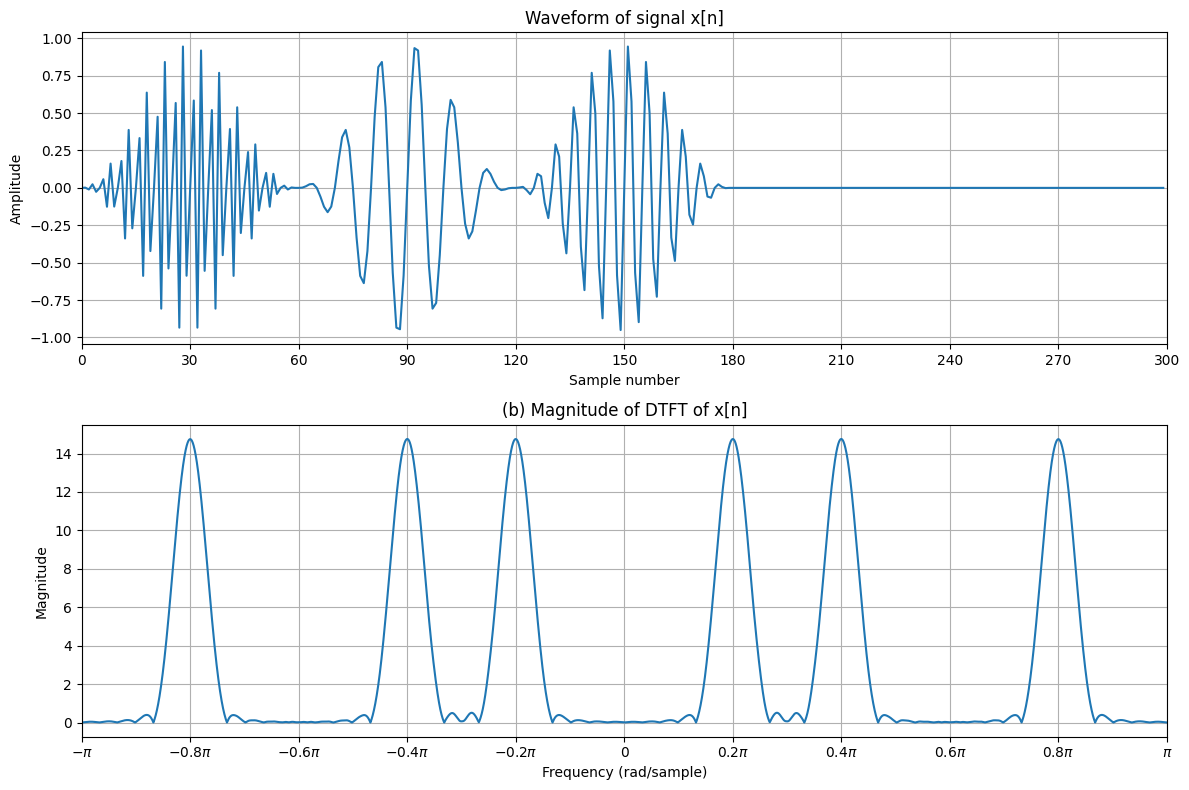

In [14]:

print("\n--- 3: Generate Input Signal ---")

# one segment length
L = 60
# Hanning Window (reduce spectral leakage)
win = np.hanning(L)

# 1. 0.8pi high frequency
n1 = np.arange(L)
x1 = np.sin(0.8 * np.pi * n1) * win

# 2. 0.2pi low frequency
n2 = np.arange(L)
x2 = np.sin(0.2 * np.pi * n2) * win

# 3. 0.4pi mid frequency
n3 = np.arange(L)
x3 = np.sin(0.4 * np.pi * n3) * win

# 4. zeros 
x4 = np.zeros(120)
# total length = 60*3 + 120 = 300

# concatenate all segments
x = np.concatenate([x1, x2, x3, x4])
# index n
n = np.arange(len(x))

print(f"Signal total length: {len(x)} samples")


# --- Analysis ---
# FFT n=44100
X = np.fft.fft(x, n=44100) 

# fftshift: shift zero to center
X_shifted = np.fft.fftshift(X)

# frequency axis from -π to π
w_fft = np.linspace(-np.pi, np.pi, len(X_shifted))


# --- draw ---
plt.figure(figsize=(12, 8))

# time domain
plt.subplot(2, 1, 1)
plt.plot(n, x)
plt.title('Waveform of signal x[n]')
plt.xlabel('Sample number')
plt.xticks(np.arange(0, 301, 30))
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim([0, 300]) 

# frequency domain
plt.subplot(2, 1, 2)
ticks = [-np.pi, -0.8*np.pi, -0.6*np.pi, -0.4*np.pi, -0.2*np.pi, 0, 0.2*np.pi, 0.4*np.pi, 0.6*np.pi, 0.8*np.pi, np.pi]
labels = [r'$-\pi$', r'$-0.8\pi$', r'$-0.6\pi$', r'$-0.4\pi$', r'$-0.2\pi$', '0', r'$0.2\pi$', r'$0.4\pi$', r'$0.6\pi$', r'$0.8\pi$', r'$\pi$']
plt.plot(w_fft, np.abs(X_shifted))
plt.title('(b) Magnitude of DTFT of x[n]')
plt.xlabel('Frequency (rad/sample)')
plt.ylabel('Magnitude')
plt.xlim([-np.pi, np.pi])

plt.xticks(ticks, labels)
plt.grid(True)

plt.tight_layout()
plt.show()

可以看出輸入訊號先 $0.8\pi$、$0.2\pi$、$0.4\pi$ ，每段各 60 samples
訊號能量集中在 $0.2\pi$、$0.4\pi$、$0.8\pi$。

## 4. LCCDE 分析輸出訊號
透過公式 $$H(z) = \frac{Y(z)}{X(z)} = \frac{b_0 + b_1z^{-1}+b_2z^{-2}+...+b_Mz^{-M}}{a_0 + a_1z^{-1}+a_2z^{-2}+...+a_Nz^{-M}}$$  
交叉相乘 $$ Y(z)\cdot (a_0 + a_1z^{-1}+a_2z^{-2}+...+a_Nz^{-M}) =X(z) \cdot (b_0 + b_1z^{-1}+b_2z^{-2}+...+b_Mz^{-M}) $$  
轉換、移項 $$y[n] = \left( \sum_{k=0}^{M} b_k x[n-k] - \sum_{k=1}^{N} a_k y[n-k] \right)$$
可以計算得出輸出訊號 y 。
接著利用 np.fft.fft() 轉為頻率，畫出後可以看出頻譜。


--- 4: LCCDE ---
LCCDE Coefficients:
b (x): [ 1.0000000e+00 -1.2006300e+01  6.9066300e+01 -2.5063920e+02
  6.3740950e+02 -1.1957780e+03  1.7028405e+03 -1.8877536e+03
  1.7217144e+03 -1.4937966e+03  1.4928141e+03 -1.6604716e+03
  1.6757650e+03 -1.3527098e+03  8.3001250e+02 -3.7391310e+02
  1.1743060e+02 -2.3164500e+01  2.1821000e+00]
a (y): [ 1.0000000e+00 -1.2761200e+01  7.9732300e+01 -3.2311170e+02
  9.4999310e+02 -2.1497026e+03  3.8780139e+03 -5.7018694e+03
  6.9280330e+03 -7.0114149e+03  5.9278596e+03 -4.1800521e+03
  2.4422871e+03 -1.1674425e+03  4.4700960e+02 -1.3246240e+02
  2.8652900e+01 -4.0462000e+00  2.8170000e-01]


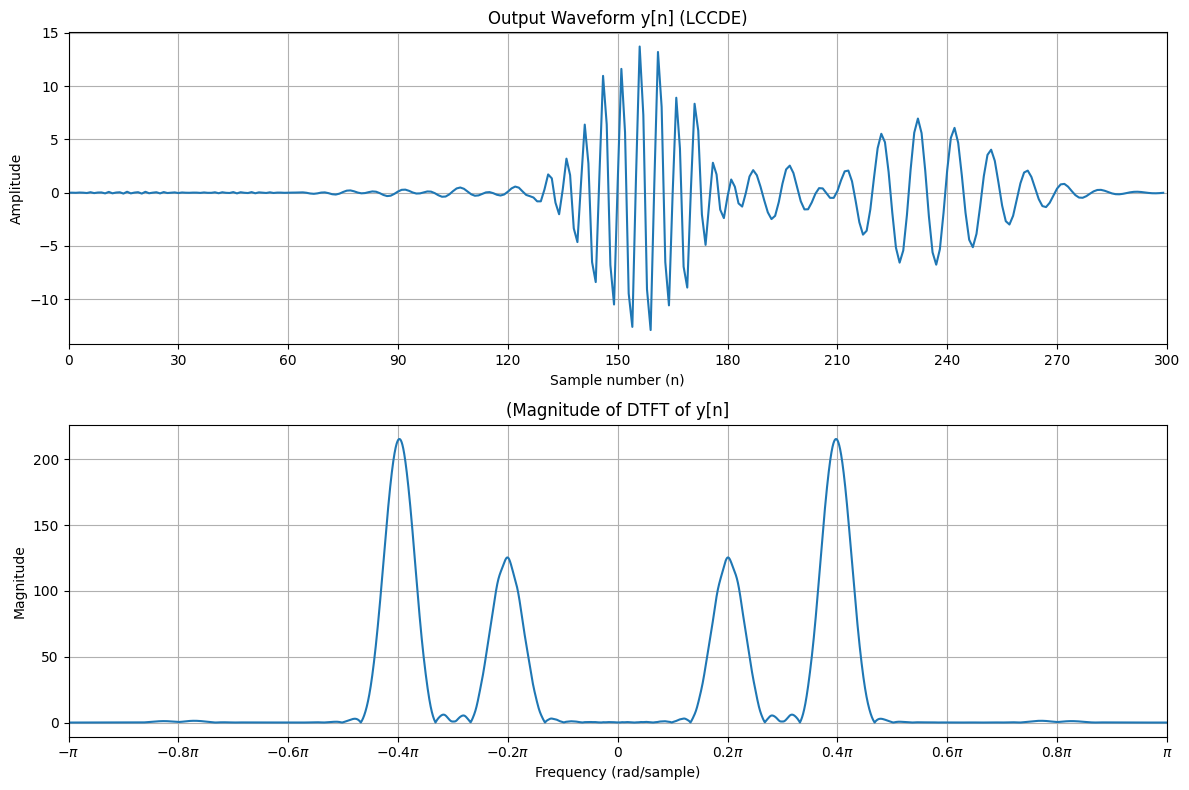

Filtering complete.


In [18]:

print("\n--- 4: LCCDE ---")

print("LCCDE Coefficients:")
print("b (x):", np.round(b, 4)) 
print("a (y):", np.round(a, 4))

# y[n] = (b0*x[n] + ... + bM*x[n-M]) - (a1*y[n-1] + ... + aN*y[n-N])

def lccde(b, a, x):
    y = np.zeros_like(x)
    M = len(b) - 1
    N = len(a) - 1
    
    # normalization 
    b_norm = b / a[0]
    a_norm = a / a[0]
    
    for n in range(len(x)):
        # x
        for k in range(M + 1):
            if n - k >= 0:
                y[n] += b_norm[k] * x[n - k]
        
        # y
        for k in range(1, N + 1):
            if n - k >= 0:
                y[n] -= a_norm[k] * y[n - k] 
    return y

# Apply LCCDE
y_out = lccde(b, a, x)

Y = np.fft.fft(y_out, n=44100)
Y_shifted = np.fft.fftshift(Y)

# --- draw ---
plt.figure(figsize=(12, 8))
# time domain
plt.subplot(2, 1, 1)
plt.plot(n, y_out)
plt.title('Output Waveform y[n] (LCCDE)')
plt.xlabel('Sample number (n)')
plt.xticks(np.arange(0, 301, 30))
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim([0, 300])

# frequency domain
plt.subplot(2, 1, 2)
plt.plot(w_fft, np.abs(Y_shifted))
plt.title('(Magnitude of DTFT of y[n]')
plt.xlabel('Frequency (rad/sample)')
plt.ylabel('Magnitude')
plt.xlim([-np.pi, np.pi])

ticks = [-np.pi, -0.8*np.pi, -0.6*np.pi, -0.4*np.pi, -0.2*np.pi, 0, 0.2*np.pi, 0.4*np.pi, 0.6*np.pi, 0.8*np.pi, np.pi]
labels = [r'$-\pi$', r'$-0.8\pi$', r'$-0.6\pi$', r'$-0.4\pi$', r'$-0.2\pi$', '0', r'$0.2\pi$', r'$0.4\pi$', r'$0.6\pi$', r'$0.8\pi$', r'$\pi$']
plt.xticks(ticks, labels)
plt.grid(True)

plt.tight_layout()
plt.show()
print("Filtering complete.")


可以看到 $0.4\pi$ 沒啥延遲，但 $0.2\pi$ 延遲了 150 samples 直到 (60+150=210) 才出現。  
頻譜也可以看到 $0.4\pi$ 變最大，$0.8\pi$ 幾乎消失了。這跟上面濾波器響應猜測的差不多。

## 5. 透過 lfilter 計算
將 a、b、輸入訊號代進 signal.lfilter(b, a, x) 即可得出輸出訊號 y 。


--- 5 : Apply Filter to Signal ---


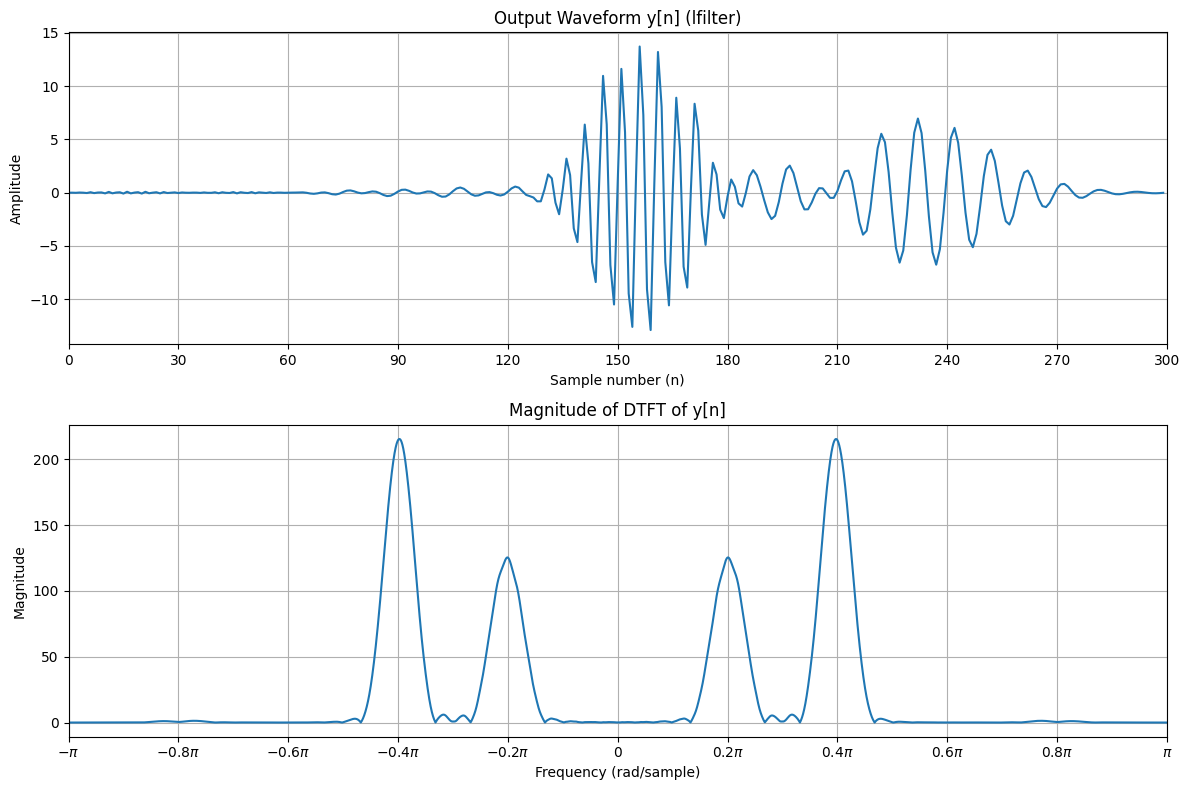

Filtering complete.


In [17]:
print("\n--- 5 : Apply Filter to Signal ---")

# lfilter
# b, a: filter coefficients
# x: input signal 
y = signal.lfilter(b, a, x)

# fft
Y = np.fft.fft(y, n=44100)
Y_shifted = np.fft.fftshift(Y)


# --- draw ---
plt.figure(figsize=(12, 8))

# time domain
plt.subplot(2, 1, 1)
plt.plot(n, y)
plt.title('Output Waveform y[n] (lfilter)')
plt.xlabel('Sample number (n)')
plt.xticks(np.arange(0, 301, 30))
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim([0, 300])

# frequency domain
plt.subplot(2, 1, 2)
plt.plot(w_fft, np.abs(Y_shifted))
plt.title('Magnitude of DTFT of y[n]')
plt.xlabel('Frequency (rad/sample)')
plt.ylabel('Magnitude')
plt.xlim([-np.pi, np.pi])

ticks = [-np.pi, -0.8*np.pi, -0.6*np.pi, -0.4*np.pi, -0.2*np.pi, 0, 0.2*np.pi, 0.4*np.pi, 0.6*np.pi, 0.8*np.pi, np.pi]
labels = [r'$-\pi$', r'$-0.8\pi$', r'$-0.6\pi$', r'$-0.4\pi$', r'$-0.2\pi$', '0', r'$0.2\pi$', r'$0.4\pi$', r'$0.6\pi$', r'$0.8\pi$', r'$\pi$']
plt.xticks(ticks, labels)
plt.grid(True)

plt.tight_layout()
plt.show()
print("Filtering complete.")

比較後可以看到和我們自己計算 LCCDE 結果幾乎一樣